In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd() / "notebooks" if (Path.cwd() / "notebooks").exists() else Path.cwd()
sys.path.insert(0, str(NOTEBOOK_DIR))
from pipeline_helpers import ARTIFACT_DIR, DATA_PATH, SEED

print(f"Data: {DATA_PATH}")
print(f"Artifacts: {ARTIFACT_DIR}")
print(f"Reproducibility seed: {SEED}")
from pipeline_helpers import phase6
result = phase6()

Data: D:\4th Semester\DS4105 - Capstone Project in Data Science II\reburn\data\raw\europe_cereal_yield_climate_1990_2022.csv
Artifacts: D:\4th Semester\DS4105 - Capstone Project in Data Science II\reburn\artifacts\cereal_yield_pipeline
Reproducibility seed: 42


## Held-out candidate comparison

All metrics below use the same untouched test observations.

In [2]:
display(result["candidate_test"])
display(result["best_selection"])

,model,AREA_ITEM_context,R2,RMSE,MAE
0,RandomForest,True,0.863480,836.049490,574.886582
1,GradientBoosting,True,0.810073,986.115899,733.326897
2,Ridge,True,0.739674,1154.497546,844.172090
3,GradientBoosting,False,0.427634,1711.871290,1284.106913
4,Ridge,False,0.360822,1809.027889,1365.062824
5,RandomForest,False,0.304099,1887.591858,1395.032577


,selected_candidate,selection_basis,best_cv_rmse
0,RandomForest|context=True,lowest training 5-fold CV RMSE,912.847846


## Full versus reduced feature set

The same model family, country/crop context choice, and fixed split are used. “Full” means every climate column actually present in the CSV plus YEAR; the prompt describes 39, while this file contains 37.

In [3]:
display(result["reduction_comparison"])

,feature_set,R2,RMSE,MAE,CV_RMSE,training_seconds,best_params
0,Reduced (15 numeric incl. YEAR),0.863480,836.049490,574.886582,912.847846,133.915501,"{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}"
1,Full (37 climate + YEAR),0.867578,823.408046,570.726597,883.525788,221.033981,"{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}"


In [4]:
reduced = result["reduction_comparison"].iloc[0]
full = result["reduction_comparison"].iloc[1]
rmse_delta = reduced["RMSE"] - full["RMSE"]
relative_delta = rmse_delta / full["RMSE"] * 100
print(f"Reduced vs. full held-out RMSE difference: {rmse_delta:.1f} ({relative_delta:.2f}% of full-set RMSE).")
print(f"R² difference (reduced - full): {reduced['R2'] - full['R2']:.4f}.")
print("The reduced set preserves close to the full set performance; the observed difference is small relative to RMSE and does not justify changing the predeclared 0.85 clustering cutoff.")

Reduced vs. full held-out RMSE difference: 12.6 (1.54% of full-set RMSE).
R² difference (reduced - full): -0.0041.
The reduced set preserves close to the full set performance; the observed difference is small relative to RMSE and does not justify changing the predeclared 0.85 clustering cutoff.


## Best model predictors

Tree models report impurity importance; Ridge reports absolute coefficients after numeric standardization. ITEM is also summarized as a feature group.

In [5]:
display(result["feature_importance"])
display(result["item_importance"])

,feature,importance,importance_type
0,numeric__WB_CCKP_TNN,0.197965,feature importance
1,categorical__ITEM_Maize (corn),0.197951,feature importance
2,numeric__WB_CCKP_HURS,0.126665,feature importance
3,numeric__WB_CCKP_TR,0.069376,feature importance
4,numeric__YEAR,0.065963,feature importance
5,numeric__WB_CCKP_PR,0.060401,feature importance
6,numeric__WB_CCKP_CDD,0.032155,feature importance
7,numeric__WB_CCKP_CWD,0.020371,feature importance
8,numeric__WB_CCKP_TX84RR,0.017612,feature importance
9,numeric__WB_CCKP_RX5DAY,0.016799,feature importance


,feature_group,aggregate_importance,rank_among_input_features
0,ITEM (crop type),0.220362,1


## Crop-level generalization and country residual checks

In [6]:
display(result["per_crop"])
display(result["per_country_worst"])

,ITEM,n,R2,RMSE,MAE
0,Barley,235,0.902208,490.889652,380.424994
1,Maize (corn),180,0.744520,1348.345549,1052.559844
2,Wheat,234,0.917482,546.011984,402.738233


,AREA,n,mean_residual,RMSE
0,Netherlands,22,403.617045,1360.365156
1,Luxembourg,15,-832.739333,1331.845290
2,Belgium,15,385.312700,1243.038677
3,Albania,20,-569.653925,1196.132161
4,Lithuania,16,-333.645813,1160.826176
5,Romania,17,-670.450824,1150.982011
6,Czechia,15,826.951767,1071.851897
7,Bosnia and Herzegovina,21,-426.733714,1067.117416
8,Germany,24,395.806104,1037.261463
9,Serbia,13,-262.277346,1002.542334


## Held-out diagnostic plots

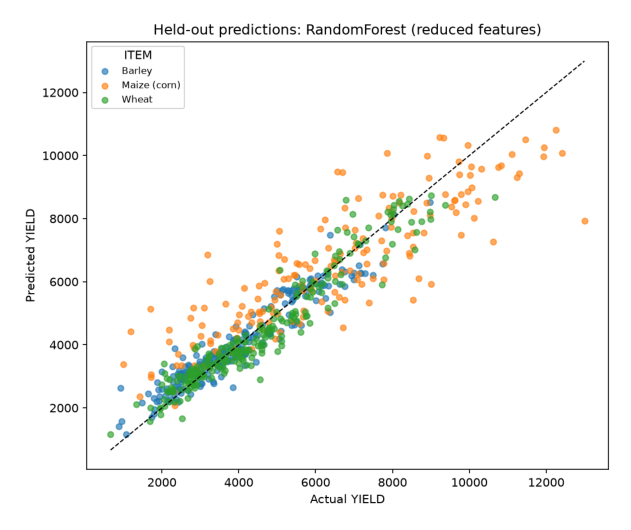

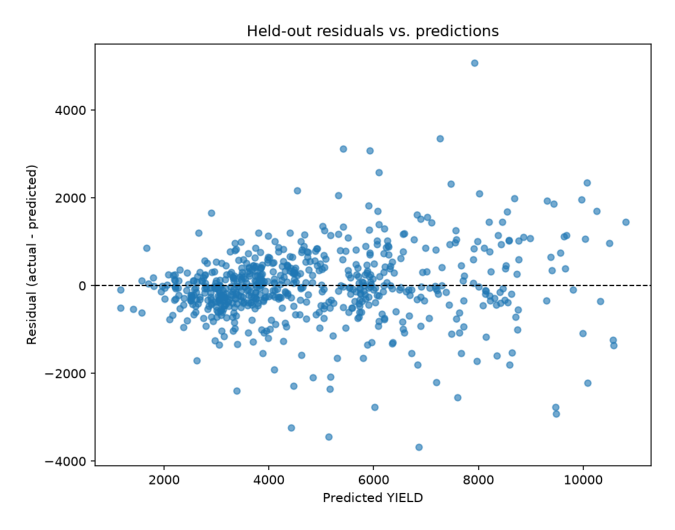

In [7]:
for image_path in [result["prediction_plot_path"], result["residual_plot_path"]]:
    image = plt.imread(image_path)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(image)
    ax.axis("off")
    display(fig)
    plt.close(fig)

The table includes R², RMSE, and MAE; diagnostics and held-out predictions are saved under `artifacts/cereal_yield_pipeline/`. The selected reduced and comparison full-feature models are saved for Phase 7 export.